In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'VGG16'
MODEL_NAME

'VGG16'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for VGG16 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics 
    norm_mean=[0.48235, 0.45882, 0.40784]
    norm_std=[0.00392156862745098, 0.00392156862745098, 0.00392156862745098]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class VGG16(nn.Module):
    """
    VGG16-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: VGG16 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained VGG16
        weights = models.VGG16_Weights.IMAGENET1K_V1
        backbone = models.vgg16(weights=weights)

        # VGG16 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 512, H, W) -> (Batch, 512, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 512, 1, 1) -> (Batch, 512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes) # VGG16 features output exactly 512 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_vgg16(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> VGG16:
    """
    Factory function to instantiate the customized VGG16 model for Transfer Learning.

    This function initializes a `VGG16` which includes:
    1. A frozen VGG16 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        VGG16Classifier: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = VGG16(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the VGG16 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-3.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_vgg16().to(device=device)

    # Summary
    print(f"\nFold: {fold_k} - Block 6")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_vgg16().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of VGG16 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of VGG16 (torchvision) Feature Indices:
    - Block 5 starts at index 23
    - Block 4 starts at index 16
    - Block 3 starts at index 9
    - Block 2 starts at index 4
    - Block 1 starts at index 0

    Args:
        model (nn.Module): The VGG16 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last convolutional block and classifier.
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 23,
        4: 16,
        3: 9,
        2: 4,
        1: 0,
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Dense layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the VGG16 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The VGG block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_vgg16().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific VGG block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_vgg16().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 6
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 192MB/s]



Fold: 1 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass size (MB): 

Epoch 1/50 | loss: 2.7686 - accuracy: 0.4496 | val_loss: 1.6611 - val_accuracy: 0.5480
val_accuracy improved from 0.0000 to 0.5480, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth


Epoch 2/50 | loss: 2.1461 - accuracy: 0.4905 | val_loss: 0.9804 - val_accuracy: 0.6125
val_accuracy improved from 0.5480 to 0.6125, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth


...

Epoch 26/50 | loss: 0.2811 - accuracy: 0.7597 | val_loss: 0.1962 - val_accuracy: 0.8155
val_accuracy did not improve from 0.8487


Epoch 27/50 | loss: 0.2570 - accuracy: 0.7815 | val_loss: 0.2116 - val_accuracy: 0.7970
val_accuracy did not improve from 0.8487


Epoch 28/50 | loss: 0.2713 - accuracy: 0.7637 | val_loss: 0.1804 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8487


Epoch 29/50 | loss: 0.2542 - accuracy: 0.7760 | val_loss: 0.1657 - val_accuracy: 0.8266
val_accuracy did not improve from 0.8487


Epoch 30/50 | loss: 0.2416 - accuracy: 0.7760 | val_loss: 0.1801 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8487
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.183754  0.848708
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.88      0.87       245
Meningioma Tumor       0.69      0.71      0.70       112
 Pituitary Tumor       0.94      0.89      0.91       185

        accuracy                           0.85       542
       macro avg       0.83      0.83      0.83       542
    weighted avg       0.85      0.85      0.85       542



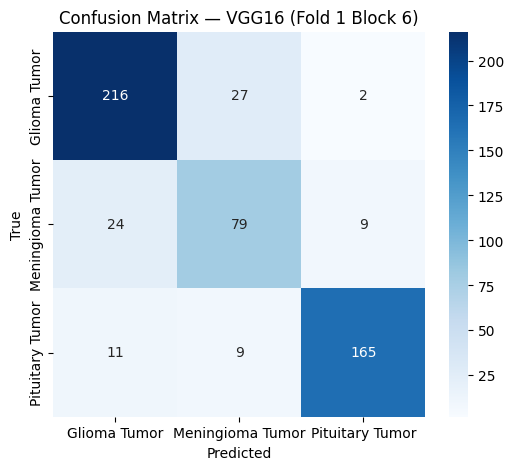

Fold: 1 block 5

Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.2574 - accuracy: 0.7772 | val_loss: 0.1502 - val_accuracy: 0.8450
val_accuracy improved from 0.0000 to 0.8450, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


Epoch 2/50 | loss: 0.2045 - accuracy: 0.7950 | val_loss: 0.1444 - val_accuracy: 0.8376
val_accuracy did not improve from 0.8450


Epoch 3/50 | loss: 0.1798 - accuracy: 0.8013 | val_loss: 0.1254 - val_accuracy: 0.8635
val_accuracy improved from 0.8450 to 0.8635, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


Epoch 4/50 | loss: 0.1473 - accuracy: 0.8339 | val_loss: 0.1173 - val_accuracy: 0.8653
val_accuracy improved from 0.8635 to 0.8653, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


...

Epoch 15/50 | loss: 0.0832 - accuracy: 0.8961 | val_loss: 0.0829 - val_accuracy: 0.8819
val_accuracy did not improve from 0.9096


Epoch 16/50 | loss: 0.0845 - accuracy: 0.8997 | val_loss: 0.0811 - val_accuracy: 0.8948
val_accuracy did not improve from 0.9096


Epoch 17/50 | loss: 0.0817 - accuracy: 0.9084 | val_loss: 0.0718 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9096


Epoch 18/50 | loss: 0.0726 - accuracy: 0.9112 | val_loss: 0.0777 - val_accuracy: 0.8948
val_accuracy did not improve from 0.9096


Epoch 19/50 | loss: 0.0705 - accuracy: 0.9155 | val_loss: 0.0744 - val_accuracy: 0.9022
val_accuracy did not improve from 0.9096
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.070193  0.909594
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.93      0.93       245
Meningioma Tumor       0.78      0.80      0.79       112
 Pituitary Tumor       0.97      0.94      0.96       185

        accuracy                           0.91       542
       macro avg       0.89      0.89      0.89       542
    weighted avg       0.91      0.91      0.91       542



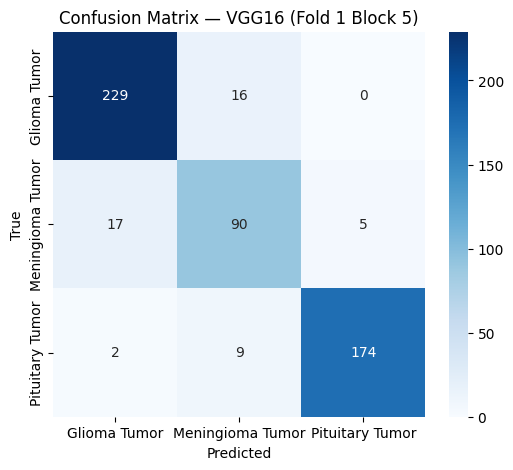

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0931 - accuracy: 0.8918 | val_loss: 0.0593 - val_accuracy: 0.9207
val_accuracy improved from 0.0000 to 0.9207, saving weights to /kaggle/working/VGG16_block_4_fold_1.pth


Epoch 2/50 | loss: 0.0828 - accuracy: 0.9040 | val_loss: 0.0703 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9207


Epoch 3/50 | loss: 0.0715 - accuracy: 0.9199 | val_loss: 0.0621 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9207


Epoch 4/50 | loss: 0.0676 - accuracy: 0.9235 | val_loss: 0.0509 - val_accuracy: 0.9225
val_accuracy improved from 0.9207 to 0.9225, saving weights to /kaggle/working/VGG16_block_4_fold_1.pth


...

Epoch 10/50 | loss: 0.0412 - accuracy: 0.9469 | val_loss: 0.0688 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9428


Epoch 11/50 | loss: 0.0375 - accuracy: 0.9512 | val_loss: 0.0560 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9428


Epoch 12/50 | loss: 0.0339 - accuracy: 0.9544 | val_loss: 0.1066 - val_accuracy: 0.9170
val_accuracy did not improve from 0.9428


Epoch 13/50 | loss: 0.0344 - accuracy: 0.9576 | val_loss: 0.0642 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9428


Epoch 14/50 | loss: 0.0301 - accuracy: 0.9667 | val_loss: 0.0740 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9428
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.041125  0.942804
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.94      0.96       245
Meningioma Tumor       0.82      0.92      0.87       112
 Pituitary Tumor       0.99      0.96      0.97       185

        accuracy                           0.94       542
       macro avg       0.93      0.94      0.93       542
    weighted avg       0.95      0.94      0.94       542



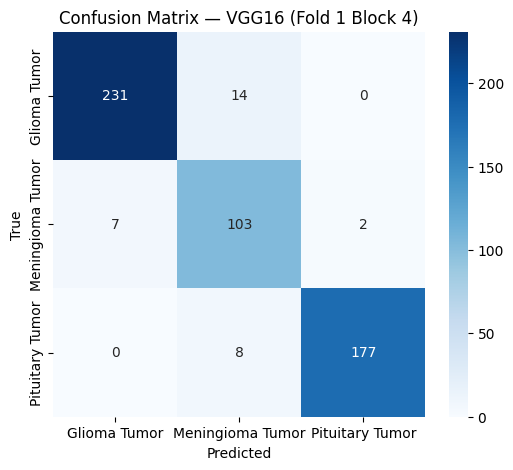

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0550 - accuracy: 0.9338 | val_loss: 0.0523 - val_accuracy: 0.9262
val_accuracy improved from 0.0000 to 0.9262, saving weights to /kaggle/working/VGG16_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0399 - accuracy: 0.9520 | val_loss: 0.0579 - val_accuracy: 0.9373
val_accuracy improved from 0.9262 to 0.9373, saving weights to /kaggle/working/VGG16_block_3_fold_1.pth


Epoch 3/50 | loss: 0.0392 - accuracy: 0.9528 | val_loss: 0.0491 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9373


Epoch 4/50 | loss: 0.0389 - accuracy: 0.9492 | val_loss: 0.0606 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9373


...

Epoch 8/50 | loss: 0.0299 - accuracy: 0.9651 | val_loss: 0.0481 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9520


Epoch 9/50 | loss: 0.0279 - accuracy: 0.9679 | val_loss: 0.0569 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9520


Epoch 10/50 | loss: 0.0228 - accuracy: 0.9726 | val_loss: 0.0616 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9520


Epoch 11/50 | loss: 0.0213 - accuracy: 0.9774 | val_loss: 0.0595 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9520


Epoch 12/50 | loss: 0.0182 - accuracy: 0.9758 | val_loss: 0.0662 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9520
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.035944   0.95203
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.97      0.96       245
Meningioma Tumor       0.90      0.88      0.89       112
 Pituitary Tumor       0.99      0.97      0.98       185

        accuracy                           0.95       542
       macro avg       0.95      0.94      0.94       542
    weighted avg       0.95      0.95      0.95       542



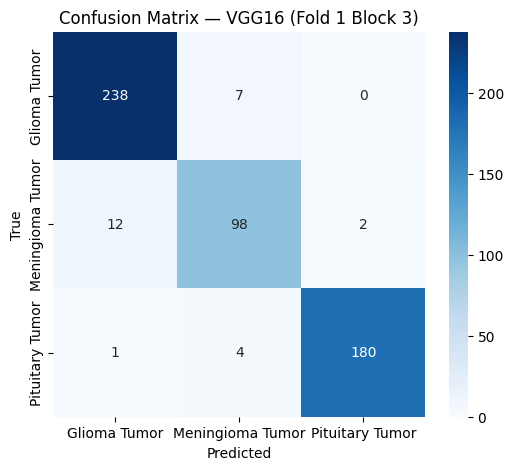

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0453 - accuracy: 0.9500 | val_loss: 0.0437 - val_accuracy: 0.9354
val_accuracy improved from 0.0000 to 0.9354, saving weights to /kaggle/working/VGG16_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0259 - accuracy: 0.9675 | val_loss: 0.0527 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9354


Epoch 3/50 | loss: 0.0283 - accuracy: 0.9663 | val_loss: 0.0942 - val_accuracy: 0.9041
val_accuracy did not improve from 0.9354


Epoch 4/50 | loss: 0.0256 - accuracy: 0.9671 | val_loss: 0.0730 - val_accuracy: 0.9170
val_accuracy did not improve from 0.9354


...

Epoch 7/50 | loss: 0.0164 - accuracy: 0.9782 | val_loss: 0.0458 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9410


Epoch 8/50 | loss: 0.0193 - accuracy: 0.9750 | val_loss: 0.0451 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9410


Epoch 9/50 | loss: 0.0155 - accuracy: 0.9786 | val_loss: 0.0476 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9410


Epoch 10/50 | loss: 0.0191 - accuracy: 0.9758 | val_loss: 0.0515 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9410


Epoch 11/50 | loss: 0.0155 - accuracy: 0.9814 | val_loss: 0.0446 - val_accuracy: 0.9317
val_accuracy did not improve from 0.9410
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.048669  0.940959
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.91      0.95       245
Meningioma Tumor       0.82      0.95      0.88       112
 Pituitary Tumor       0.98      0.97      0.98       185

        accuracy                           0.94       542
       macro avg       0.93      0.94      0.93       542
    weighted avg       0.95      0.94      0.94       542



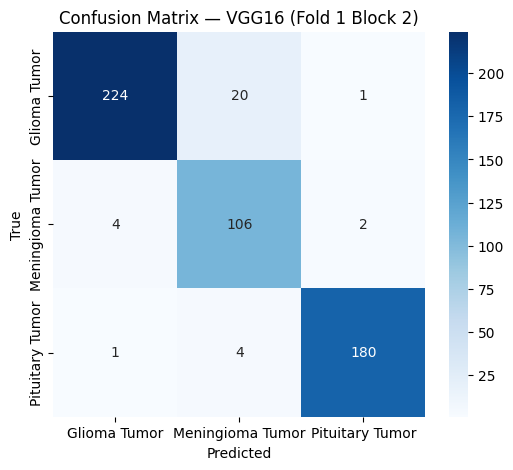

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0270 - accuracy: 0.9687 | val_loss: 0.0728 - val_accuracy: 0.9188
val_accuracy improved from 0.0000 to 0.9188, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0291 - accuracy: 0.9707 | val_loss: 0.0890 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9188


Epoch 3/50 | loss: 0.0187 - accuracy: 0.9770 | val_loss: 0.0493 - val_accuracy: 0.9410
val_accuracy improved from 0.9188 to 0.9410, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


Epoch 4/50 | loss: 0.0251 - accuracy: 0.9703 | val_loss: 0.0464 - val_accuracy: 0.9446
val_accuracy improved from 0.9410 to 0.9446, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


...

Epoch 13/50 | loss: 0.0153 - accuracy: 0.9802 | val_loss: 0.0448 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9631


Epoch 14/50 | loss: 0.0088 - accuracy: 0.9901 | val_loss: 0.0424 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9631


Epoch 15/50 | loss: 0.0108 - accuracy: 0.9861 | val_loss: 0.0478 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9631


Epoch 16/50 | loss: 0.0088 - accuracy: 0.9889 | val_loss: 0.0433 - val_accuracy: 0.9502
val_accuracy did not improve from 0.9631


Epoch 17/50 | loss: 0.0082 - accuracy: 0.9885 | val_loss: 0.0404 - val_accuracy: 0.9502
val_accuracy did not improve from 0.9631
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.038974    0.9631
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       245
Meningioma Tumor       0.90      0.92      0.91       112
 Pituitary Tumor       0.99      0.98      0.98       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.96       542
    weighted avg       0.96      0.96      0.96       542



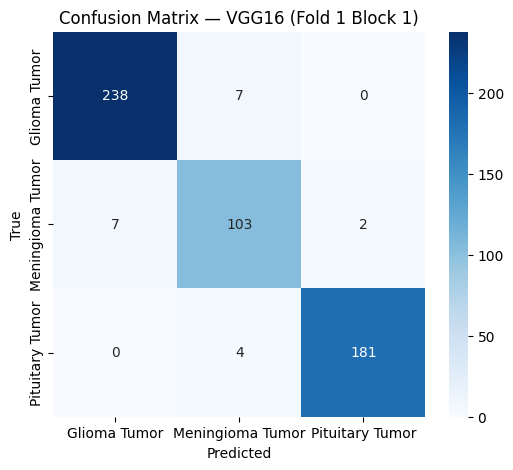

Fold: 2 block 6

Fold: 2 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 2.3952 - accuracy: 0.4625 | val_loss: 1.1318 - val_accuracy: 0.5449
val_accuracy improved from 0.0000 to 0.5449, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 2/50 | loss: 2.0533 - accuracy: 0.4881 | val_loss: 0.9909 - val_accuracy: 0.5817
val_accuracy improved from 0.5449 to 0.5817, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 3/50 | loss: 1.7322 - accuracy: 0.5287 | val_loss: 0.6915 - val_accuracy: 0.6686
val_accuracy improved from 0.5817 to 0.6686, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 4/50 | loss: 1.6009 - accuracy: 0.5551 | val_loss: 0.6087 - val_accuracy: 0.6775
val_accuracy improved from 0.6686 to 0.6775, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


...

Epoch 22/50 | loss: 0.4014 - accuracy: 0.7484 | val_loss: 0.1906 - val_accuracy: 0.8085
val_accuracy did not improve from 0.8189


Epoch 23/50 | loss: 0.3591 - accuracy: 0.7463 | val_loss: 0.1805 - val_accuracy: 0.8144
val_accuracy did not improve from 0.8189


Epoch 24/50 | loss: 0.3443 - accuracy: 0.7581 | val_loss: 0.2365 - val_accuracy: 0.8012
val_accuracy did not improve from 0.8189


Epoch 25/50 | loss: 0.3365 - accuracy: 0.7597 | val_loss: 0.1808 - val_accuracy: 0.8174
val_accuracy did not improve from 0.8189


Epoch 26/50 | loss: 0.2875 - accuracy: 0.7761 | val_loss: 0.1981 - val_accuracy: 0.8130
val_accuracy did not improve from 0.8189
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.199185  0.818851
                  precision    recall  f1-score   support

    Glioma Tumor       0.84      0.86      0.85       338
Meningioma Tumor       0.66      0.62      0.64       167
 Pituitary Tumor       0.91      0.93      0.92       174

        accuracy                           0.82       679
       macro avg       0.81      0.80      0.80       679
    weighted avg       0.82      0.82      0.82       679



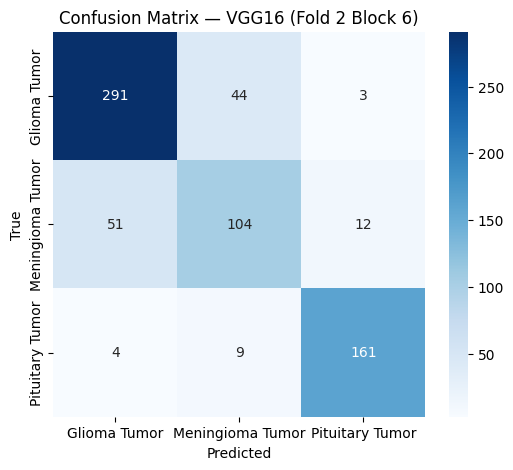

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.2977 - accuracy: 0.7593 | val_loss: 0.1618 - val_accuracy: 0.8174
val_accuracy improved from 0.0000 to 0.8174, saving weights to /kaggle/working/VGG16_block_5_fold_2.pth


Epoch 2/50 | loss: 0.2490 - accuracy: 0.7732 | val_loss: 0.1627 - val_accuracy: 0.8085
val_accuracy did not improve from 0.8174


Epoch 3/50 | loss: 0.1990 - accuracy: 0.8109 | val_loss: 0.1607 - val_accuracy: 0.8144
val_accuracy did not improve from 0.8174


Epoch 4/50 | loss: 0.1830 - accuracy: 0.8071 | val_loss: 0.1414 - val_accuracy: 0.8380
val_accuracy improved from 0.8174 to 0.8380, saving weights to /kaggle/working/VGG16_block_5_fold_2.pth


...

Epoch 22/50 | loss: 0.0650 - accuracy: 0.9149 | val_loss: 0.1208 - val_accuracy: 0.8778
val_accuracy did not improve from 0.8837


Epoch 23/50 | loss: 0.0731 - accuracy: 0.9157 | val_loss: 0.1211 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8837


Epoch 24/50 | loss: 0.0681 - accuracy: 0.9208 | val_loss: 0.1206 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8837


Epoch 25/50 | loss: 0.0595 - accuracy: 0.9241 | val_loss: 0.1204 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8837


Epoch 26/50 | loss: 0.0727 - accuracy: 0.9115 | val_loss: 0.1199 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8837
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.119168  0.883652
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.93      0.91       338
Meningioma Tumor       0.84      0.71      0.77       167
 Pituitary Tumor       0.89      0.96      0.93       174

        accuracy                           0.88       679
       macro avg       0.88      0.87      0.87       679
    weighted avg       0.88      0.88      0.88       679



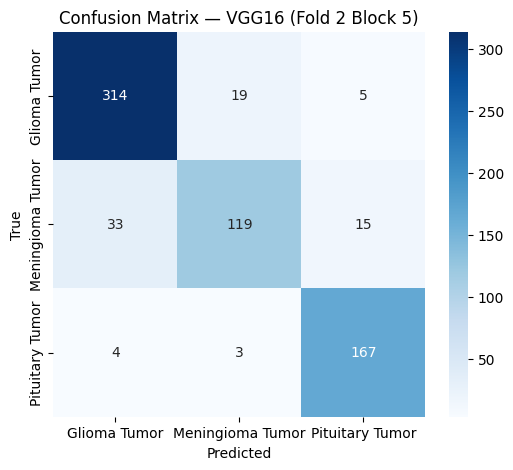

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0799 - accuracy: 0.9119 | val_loss: 0.1380 - val_accuracy: 0.8571
val_accuracy improved from 0.0000 to 0.8571, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


Epoch 2/50 | loss: 0.0751 - accuracy: 0.9166 | val_loss: 0.1211 - val_accuracy: 0.8689
val_accuracy improved from 0.8571 to 0.8689, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


Epoch 3/50 | loss: 0.0570 - accuracy: 0.9338 | val_loss: 0.1189 - val_accuracy: 0.8881
val_accuracy improved from 0.8689 to 0.8881, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


Epoch 4/50 | loss: 0.0594 - accuracy: 0.9283 | val_loss: 0.1026 - val_accuracy: 0.8910
val_accuracy improved from 0.8881 to 0.8910, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


...

Epoch 17/50 | loss: 0.0235 - accuracy: 0.9706 | val_loss: 0.1207 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9249


Epoch 18/50 | loss: 0.0267 - accuracy: 0.9656 | val_loss: 0.0918 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9249


Epoch 19/50 | loss: 0.0243 - accuracy: 0.9719 | val_loss: 0.1055 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9249


Epoch 20/50 | loss: 0.0156 - accuracy: 0.9807 | val_loss: 0.1034 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9249


Epoch 21/50 | loss: 0.0233 - accuracy: 0.9736 | val_loss: 0.1167 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9249
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.085621   0.92489
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.94      0.94       338
Meningioma Tumor       0.86      0.87      0.87       167
 Pituitary Tumor       0.98      0.94      0.96       174

        accuracy                           0.92       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.93      0.92      0.93       679



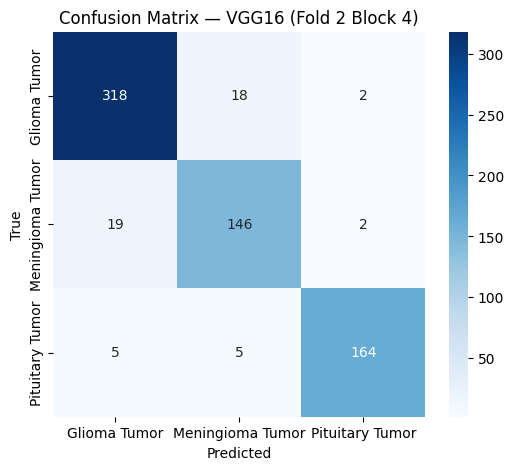

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0333 - accuracy: 0.9644 | val_loss: 0.1649 - val_accuracy: 0.8763
val_accuracy improved from 0.0000 to 0.8763, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0350 - accuracy: 0.9639 | val_loss: 0.1428 - val_accuracy: 0.8969
val_accuracy improved from 0.8763 to 0.8969, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0259 - accuracy: 0.9694 | val_loss: 0.0904 - val_accuracy: 0.9190
val_accuracy improved from 0.8969 to 0.9190, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


Epoch 4/50 | loss: 0.0227 - accuracy: 0.9698 | val_loss: 0.1017 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9190


...

Epoch 12/50 | loss: 0.0111 - accuracy: 0.9874 | val_loss: 0.1109 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9249


Epoch 13/50 | loss: 0.0126 - accuracy: 0.9832 | val_loss: 0.1074 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9249


Epoch 14/50 | loss: 0.0119 - accuracy: 0.9836 | val_loss: 0.1102 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9249


Epoch 15/50 | loss: 0.0145 - accuracy: 0.9786 | val_loss: 0.1066 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9249


Epoch 16/50 | loss: 0.0124 - accuracy: 0.9857 | val_loss: 0.1081 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9249
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.105557   0.92489
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       338
Meningioma Tumor       0.86      0.88      0.87       167
 Pituitary Tumor       0.96      0.95      0.96       174

        accuracy                           0.92       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.93      0.92      0.93       679



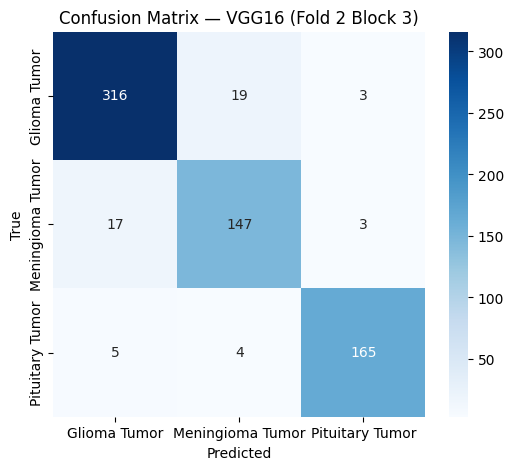

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0201 - accuracy: 0.9753 | val_loss: 0.1184 - val_accuracy: 0.9175
val_accuracy improved from 0.0000 to 0.9175, saving weights to /kaggle/working/VGG16_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0180 - accuracy: 0.9782 | val_loss: 0.1319 - val_accuracy: 0.9043
val_accuracy did not improve from 0.9175


Epoch 3/50 | loss: 0.0181 - accuracy: 0.9828 | val_loss: 0.0901 - val_accuracy: 0.9278
val_accuracy improved from 0.9175 to 0.9278, saving weights to /kaggle/working/VGG16_block_2_fold_2.pth


Epoch 4/50 | loss: 0.0205 - accuracy: 0.9786 | val_loss: 0.1082 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9278


...

Epoch 12/50 | loss: 0.0096 - accuracy: 0.9883 | val_loss: 0.1073 - val_accuracy: 0.9278
val_accuracy did not improve from 0.9308


Epoch 13/50 | loss: 0.0071 - accuracy: 0.9929 | val_loss: 0.1015 - val_accuracy: 0.9308
val_accuracy did not improve from 0.9308


Epoch 14/50 | loss: 0.0109 - accuracy: 0.9836 | val_loss: 0.1031 - val_accuracy: 0.9293
val_accuracy did not improve from 0.9308


Epoch 15/50 | loss: 0.0074 - accuracy: 0.9887 | val_loss: 0.1027 - val_accuracy: 0.9308
val_accuracy did not improve from 0.9308


Epoch 16/50 | loss: 0.0069 - accuracy: 0.9899 | val_loss: 0.1029 - val_accuracy: 0.9308
val_accuracy did not improve from 0.9308
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.093147  0.930781
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.96      0.95       338
Meningioma Tumor       0.90      0.85      0.88       167
 Pituitary Tumor       0.95      0.95      0.95       174

        accuracy                           0.93       679
       macro avg       0.93      0.92      0.92       679
    weighted avg       0.93      0.93      0.93       679



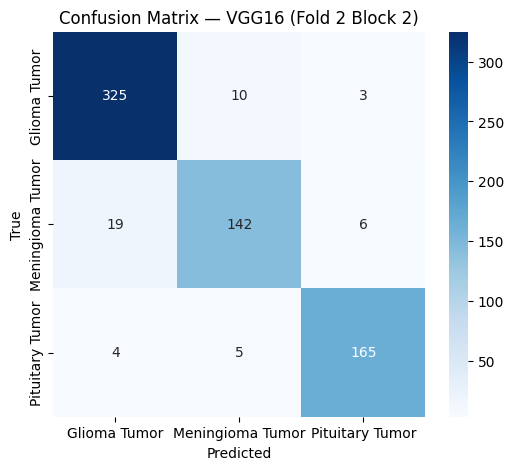

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0153 - accuracy: 0.9849 | val_loss: 0.1022 - val_accuracy: 0.9293
val_accuracy improved from 0.0000 to 0.9293, saving weights to /kaggle/working/VGG16_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0139 - accuracy: 0.9824 | val_loss: 0.1111 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9293


Epoch 3/50 | loss: 0.0182 - accuracy: 0.9778 | val_loss: 0.1107 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9293


Epoch 4/50 | loss: 0.0151 - accuracy: 0.9824 | val_loss: 0.0959 - val_accuracy: 0.9131
val_accuracy did not improve from 0.9293


Epoch 5/50 | loss: 0.0140 - accuracy: 0.9836 | val_loss: 0.1032 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9293


Epoch 6/50 | loss: 0.0137 - accuracy: 0.9853 | val_loss: 0.2394 - val_accuracy: 0.8675
val_accuracy did not improve from 0.9293


Epoch 7/50 | loss: 0.0117 - accuracy: 0.9878 | val_loss: 0.1560 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9293
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.102185  0.929308
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.95      0.95       338
Meningioma Tumor       0.87      0.87      0.87       167
 Pituitary Tumor       0.96      0.95      0.95       174

        accuracy                           0.93       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.93      0.93      0.93       679



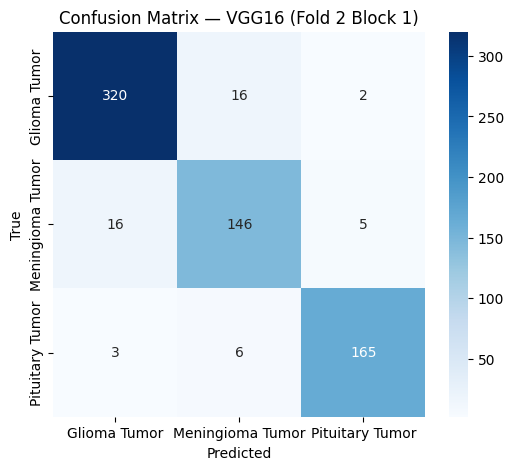

Fold: 3 block 6

Fold: 3 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 2.7308 - accuracy: 0.4446 | val_loss: 1.2514 - val_accuracy: 0.5647
val_accuracy improved from 0.0000 to 0.5647, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 2/50 | loss: 2.1070 - accuracy: 0.4976 | val_loss: 0.9508 - val_accuracy: 0.6399
val_accuracy improved from 0.5647 to 0.6399, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 3/50 | loss: 1.7298 - accuracy: 0.5437 | val_loss: 0.8010 - val_accuracy: 0.6818
val_accuracy improved from 0.6399 to 0.6818, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 4/50 | loss: 1.5894 - accuracy: 0.5574 | val_loss: 0.5829 - val_accuracy: 0.7378
val_accuracy improved from 0.6818 to 0.7378, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


...

Epoch 33/50 | loss: 0.2453 - accuracy: 0.7677 | val_loss: 0.1694 - val_accuracy: 0.8234
val_accuracy did not improve from 0.8462


Epoch 34/50 | loss: 0.2293 - accuracy: 0.7873 | val_loss: 0.1398 - val_accuracy: 0.8444
val_accuracy did not improve from 0.8462


Epoch 35/50 | loss: 0.2244 - accuracy: 0.7777 | val_loss: 0.1521 - val_accuracy: 0.8322
val_accuracy did not improve from 0.8462


Epoch 36/50 | loss: 0.2379 - accuracy: 0.7785 | val_loss: 0.1439 - val_accuracy: 0.8444
val_accuracy did not improve from 0.8462


Epoch 37/50 | loss: 0.2222 - accuracy: 0.7849 | val_loss: 0.1413 - val_accuracy: 0.8444
val_accuracy did not improve from 0.8462
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.148307  0.846154
                  precision    recall  f1-score   support

    Glioma Tumor       0.81      0.90      0.85       231
Meningioma Tumor       0.81      0.62      0.70       139
 Pituitary Tumor       0.91      0.95      0.92       202

        accuracy                           0.85       572
       macro avg       0.84      0.82      0.83       572
    weighted avg       0.84      0.85      0.84       572



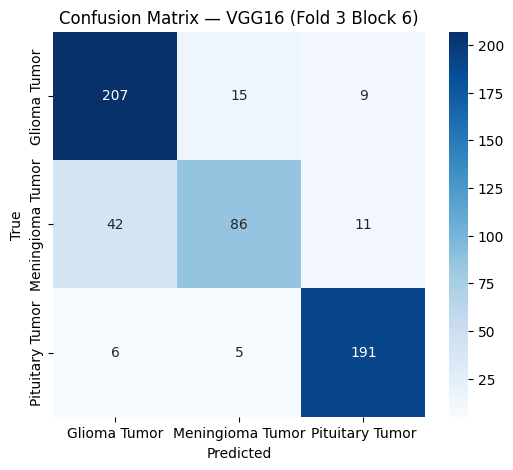

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.2371 - accuracy: 0.7648 | val_loss: 0.1485 - val_accuracy: 0.8234
val_accuracy improved from 0.0000 to 0.8234, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


Epoch 2/50 | loss: 0.1790 - accuracy: 0.8026 | val_loss: 0.1286 - val_accuracy: 0.8619
val_accuracy improved from 0.8234 to 0.8619, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


Epoch 3/50 | loss: 0.1567 - accuracy: 0.8242 | val_loss: 0.1217 - val_accuracy: 0.8584
val_accuracy did not improve from 0.8619


Epoch 4/50 | loss: 0.1567 - accuracy: 0.8323 | val_loss: 0.1147 - val_accuracy: 0.8706
val_accuracy improved from 0.8619 to 0.8706, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


...

Epoch 18/50 | loss: 0.0760 - accuracy: 0.9121 | val_loss: 0.0922 - val_accuracy: 0.8986
val_accuracy did not improve from 0.9021


Epoch 19/50 | loss: 0.0671 - accuracy: 0.9246 | val_loss: 0.0964 - val_accuracy: 0.8916
val_accuracy did not improve from 0.9021


Epoch 20/50 | loss: 0.0737 - accuracy: 0.9169 | val_loss: 0.0975 - val_accuracy: 0.8934
val_accuracy did not improve from 0.9021


Epoch 21/50 | loss: 0.0665 - accuracy: 0.9246 | val_loss: 0.0943 - val_accuracy: 0.8951
val_accuracy did not improve from 0.9021


Epoch 22/50 | loss: 0.0564 - accuracy: 0.9306 | val_loss: 0.0956 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9021
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.090893  0.902098
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.92      0.91       231
Meningioma Tumor       0.82      0.80      0.81       139
 Pituitary Tumor       0.96      0.96      0.96       202

        accuracy                           0.90       572
       macro avg       0.89      0.89      0.89       572
    weighted avg       0.90      0.90      0.90       572



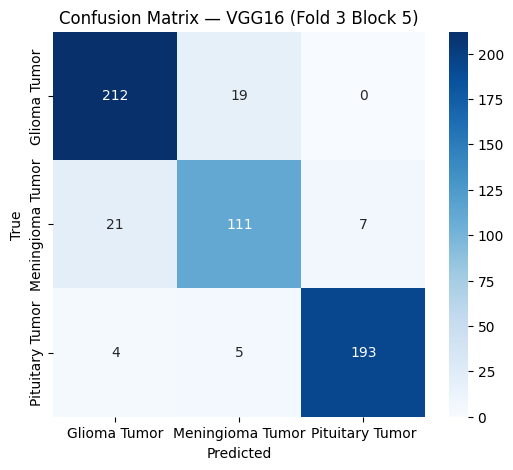

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0812 - accuracy: 0.9101 | val_loss: 0.0866 - val_accuracy: 0.8969
val_accuracy improved from 0.0000 to 0.8969, saving weights to /kaggle/working/VGG16_block_4_fold_3.pth


Epoch 2/50 | loss: 0.0649 - accuracy: 0.9270 | val_loss: 0.0852 - val_accuracy: 0.9108
val_accuracy improved from 0.8969 to 0.9108, saving weights to /kaggle/working/VGG16_block_4_fold_3.pth


Epoch 3/50 | loss: 0.0582 - accuracy: 0.9266 | val_loss: 0.0896 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9108


Epoch 4/50 | loss: 0.0544 - accuracy: 0.9382 | val_loss: 0.0845 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9108


...

Epoch 12/50 | loss: 0.0318 - accuracy: 0.9663 | val_loss: 0.0835 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9318


Epoch 13/50 | loss: 0.0287 - accuracy: 0.9635 | val_loss: 0.0855 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9318


Epoch 14/50 | loss: 0.0296 - accuracy: 0.9671 | val_loss: 0.0837 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9318


Epoch 15/50 | loss: 0.0291 - accuracy: 0.9643 | val_loss: 0.0803 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9318


Epoch 16/50 | loss: 0.0260 - accuracy: 0.9675 | val_loss: 0.0825 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9318
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.078421  0.931818
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       231
Meningioma Tumor       0.86      0.88      0.87       139
 Pituitary Tumor       0.98      0.97      0.97       202

        accuracy                           0.93       572
       macro avg       0.93      0.93      0.93       572
    weighted avg       0.93      0.93      0.93       572



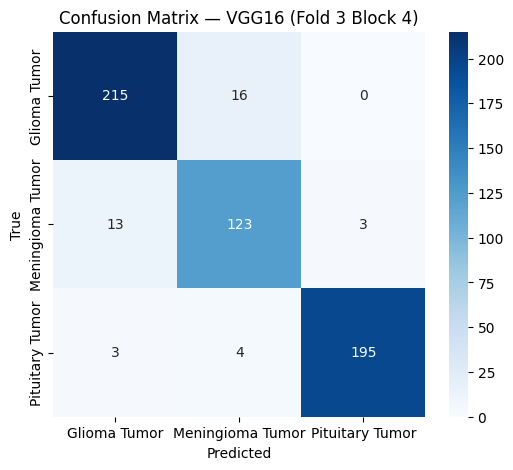

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0400 - accuracy: 0.9587 | val_loss: 0.0712 - val_accuracy: 0.9248
val_accuracy improved from 0.0000 to 0.9248, saving weights to /kaggle/working/VGG16_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0321 - accuracy: 0.9659 | val_loss: 0.0704 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9248


Epoch 3/50 | loss: 0.0296 - accuracy: 0.9687 | val_loss: 0.0837 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9248


Epoch 4/50 | loss: 0.0329 - accuracy: 0.9615 | val_loss: 0.0915 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9248


Epoch 5/50 | loss: 0.0319 - accuracy: 0.9575 | val_loss: 0.0992 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9248


Epoch 6/50 | loss: 0.0310 - accuracy: 0.9583 | val_loss: 0.0852 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9248


Epoch 7/50 | loss: 0.0227 - accuracy: 0.9731 | val_loss: 0.0843 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9248
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.071169  0.924825
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.92      0.92       231
Meningioma Tumor       0.86      0.86      0.86       139
 Pituitary Tumor       0.97      0.97      0.97       202

        accuracy                           0.92       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.92      0.92      0.92       572



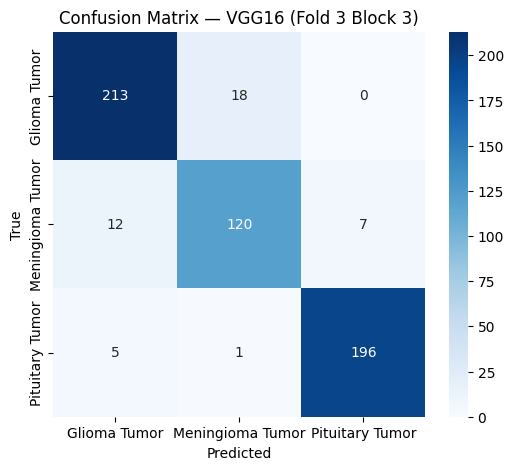

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0377 - accuracy: 0.9591 | val_loss: 0.0796 - val_accuracy: 0.9178
val_accuracy improved from 0.0000 to 0.9178, saving weights to /kaggle/working/VGG16_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0297 - accuracy: 0.9655 | val_loss: 0.0853 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9178


Epoch 3/50 | loss: 0.0269 - accuracy: 0.9675 | val_loss: 0.0847 - val_accuracy: 0.9231
val_accuracy improved from 0.9178 to 0.9231, saving weights to /kaggle/working/VGG16_block_2_fold_3.pth


Epoch 4/50 | loss: 0.0333 - accuracy: 0.9595 | val_loss: 0.0726 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9231


Epoch 5/50 | loss: 0.0341 - accuracy: 0.9651 | val_loss: 0.0973 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9231


Epoch 6/50 | loss: 0.0246 - accuracy: 0.9711 | val_loss: 0.0846 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9231


Epoch 7/50 | loss: 0.0268 - accuracy: 0.9667 | val_loss: 0.1052 - val_accuracy: 0.8776
val_accuracy did not improve from 0.9231


Epoch 8/50 | loss: 0.0221 - accuracy: 0.9687 | val_loss: 0.1401 - val_accuracy: 0.9003
val_accuracy did not improve from 0.9231


Epoch 9/50 | loss: 0.0195 - accuracy: 0.9795 | val_loss: 0.0818 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9231
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.084718  0.923077
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.92      0.93       231
Meningioma Tumor       0.86      0.83      0.85       139
 Pituitary Tumor       0.95      0.99      0.97       202

        accuracy                           0.92       572
       macro avg       0.92      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



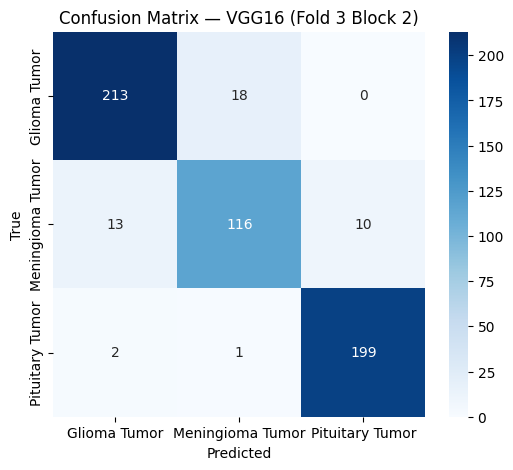

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0316 - accuracy: 0.9639 | val_loss: 0.0852 - val_accuracy: 0.9003
val_accuracy improved from 0.0000 to 0.9003, saving weights to /kaggle/working/VGG16_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0328 - accuracy: 0.9599 | val_loss: 0.0724 - val_accuracy: 0.9143
val_accuracy improved from 0.9003 to 0.9143, saving weights to /kaggle/working/VGG16_block_1_fold_3.pth


Epoch 3/50 | loss: 0.0238 - accuracy: 0.9747 | val_loss: 0.0680 - val_accuracy: 0.9266
val_accuracy improved from 0.9143 to 0.9266, saving weights to /kaggle/working/VGG16_block_1_fold_3.pth


Epoch 4/50 | loss: 0.0258 - accuracy: 0.9711 | val_loss: 0.0762 - val_accuracy: 0.9283
val_accuracy improved from 0.9266 to 0.9283, saving weights to /kaggle/working/VGG16_block_1_fold_3.pth


...

Epoch 9/50 | loss: 0.0149 - accuracy: 0.9795 | val_loss: 0.0755 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9318


Epoch 10/50 | loss: 0.0132 - accuracy: 0.9864 | val_loss: 0.0738 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9318


Epoch 11/50 | loss: 0.0148 - accuracy: 0.9823 | val_loss: 0.0770 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318


Epoch 12/50 | loss: 0.0137 - accuracy: 0.9864 | val_loss: 0.0776 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9318


Epoch 13/50 | loss: 0.0117 - accuracy: 0.9864 | val_loss: 0.0784 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9318
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.068284  0.931818
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.93      0.93       231
Meningioma Tumor       0.87      0.86      0.87       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



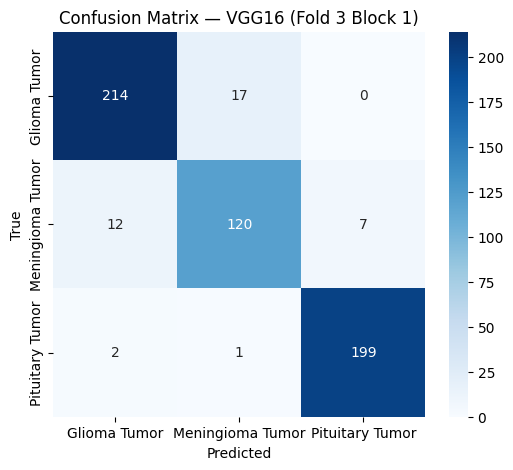

Fold: 4 block 6

Fold: 4 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 5.1399 - accuracy: 0.2890 | val_loss: 2.1157 - val_accuracy: 0.3041
val_accuracy improved from 0.0000 to 0.3041, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 2/50 | loss: 3.4861 - accuracy: 0.3530 | val_loss: 1.2744 - val_accuracy: 0.4618
val_accuracy improved from 0.3041 to 0.4618, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 3/50 | loss: 2.7774 - accuracy: 0.3949 | val_loss: 0.8417 - val_accuracy: 0.6146
val_accuracy improved from 0.4618 to 0.6146, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 4/50 | loss: 2.0503 - accuracy: 0.4967 | val_loss: 0.6830 - val_accuracy: 0.6545
val_accuracy improved from 0.6146 to 0.6545, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


...

Epoch 26/50 | loss: 0.3371 - accuracy: 0.7455 | val_loss: 0.1665 - val_accuracy: 0.8360
val_accuracy did not improve from 0.8567


Epoch 27/50 | loss: 0.3481 - accuracy: 0.7328 | val_loss: 0.1841 - val_accuracy: 0.8408
val_accuracy did not improve from 0.8567


Epoch 28/50 | loss: 0.3089 - accuracy: 0.7566 | val_loss: 0.1442 - val_accuracy: 0.8455
val_accuracy did not improve from 0.8567


Epoch 29/50 | loss: 0.2979 - accuracy: 0.7701 | val_loss: 0.1436 - val_accuracy: 0.8471
val_accuracy did not improve from 0.8567


Epoch 30/50 | loss: 0.2842 - accuracy: 0.7771 | val_loss: 0.1462 - val_accuracy: 0.8471
val_accuracy did not improve from 0.8567
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.152517  0.856688
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.89      0.89       325
Meningioma Tumor       0.69      0.65      0.67       124
 Pituitary Tumor       0.90      0.94      0.92       179

        accuracy                           0.86       628
       macro avg       0.83      0.83      0.83       628
    weighted avg       0.85      0.86      0.86       628



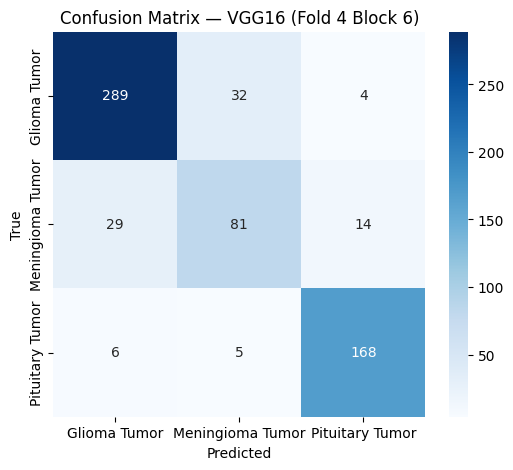

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.3180 - accuracy: 0.7422 | val_loss: 0.1228 - val_accuracy: 0.8583
val_accuracy improved from 0.0000 to 0.8583, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 2/50 | loss: 0.2215 - accuracy: 0.7779 | val_loss: 0.1230 - val_accuracy: 0.8615
val_accuracy improved from 0.8583 to 0.8615, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 3/50 | loss: 0.1939 - accuracy: 0.8038 | val_loss: 0.1129 - val_accuracy: 0.8678
val_accuracy improved from 0.8615 to 0.8678, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 4/50 | loss: 0.1781 - accuracy: 0.8116 | val_loss: 0.1144 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8678


...

Epoch 16/50 | loss: 0.0940 - accuracy: 0.8945 | val_loss: 0.0750 - val_accuracy: 0.9045
val_accuracy did not improve from 0.9061


Epoch 17/50 | loss: 0.0854 - accuracy: 0.8978 | val_loss: 0.0809 - val_accuracy: 0.8949
val_accuracy did not improve from 0.9061


Epoch 18/50 | loss: 0.0868 - accuracy: 0.8941 | val_loss: 0.0752 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9061


Epoch 19/50 | loss: 0.0753 - accuracy: 0.9093 | val_loss: 0.0741 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9061


Epoch 20/50 | loss: 0.0746 - accuracy: 0.9085 | val_loss: 0.0759 - val_accuracy: 0.9013
val_accuracy did not improve from 0.9061
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG16  0.07467  0.906051
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.95      0.94       325
Meningioma Tumor       0.82      0.72      0.76       124
 Pituitary Tumor       0.93      0.95      0.94       179

        accuracy                           0.91       628
       macro avg       0.89      0.87      0.88       628
    weighted avg       0.90      0.91      0.90       628



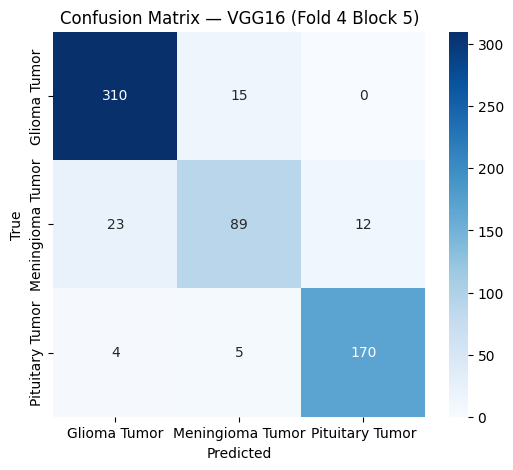

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0963 - accuracy: 0.8908 | val_loss: 0.0824 - val_accuracy: 0.9045
val_accuracy improved from 0.0000 to 0.9045, saving weights to /kaggle/working/VGG16_block_4_fold_4.pth


Epoch 2/50 | loss: 0.0782 - accuracy: 0.9035 | val_loss: 0.0688 - val_accuracy: 0.9188
val_accuracy improved from 0.9045 to 0.9188, saving weights to /kaggle/working/VGG16_block_4_fold_4.pth


Epoch 3/50 | loss: 0.0780 - accuracy: 0.9126 | val_loss: 0.0710 - val_accuracy: 0.9204
val_accuracy improved from 0.9188 to 0.9204, saving weights to /kaggle/working/VGG16_block_4_fold_4.pth


Epoch 4/50 | loss: 0.0654 - accuracy: 0.9216 | val_loss: 0.0687 - val_accuracy: 0.9172
val_accuracy did not improve from 0.9204


...

Epoch 13/50 | loss: 0.0346 - accuracy: 0.9610 | val_loss: 0.0689 - val_accuracy: 0.9315
val_accuracy did not improve from 0.9315


Epoch 14/50 | loss: 0.0416 - accuracy: 0.9553 | val_loss: 0.0690 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9315


Epoch 15/50 | loss: 0.0384 - accuracy: 0.9528 | val_loss: 0.0675 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9315


Epoch 16/50 | loss: 0.0347 - accuracy: 0.9618 | val_loss: 0.0692 - val_accuracy: 0.9268
val_accuracy did not improve from 0.9315


Epoch 17/50 | loss: 0.0366 - accuracy: 0.9557 | val_loss: 0.0684 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9315
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.068604  0.931529
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.98      0.95       325
Meningioma Tumor       0.87      0.82      0.85       124
 Pituitary Tumor       0.97      0.93      0.95       179

        accuracy                           0.93       628
       macro avg       0.92      0.91      0.92       628
    weighted avg       0.93      0.93      0.93       628



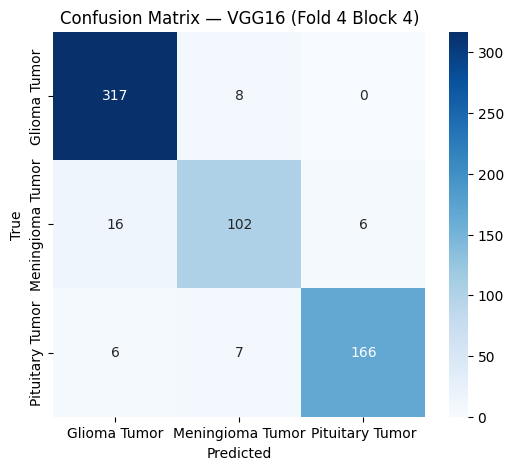

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0489 - accuracy: 0.9438 | val_loss: 0.0718 - val_accuracy: 0.9379
val_accuracy improved from 0.0000 to 0.9379, saving weights to /kaggle/working/VGG16_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0449 - accuracy: 0.9454 | val_loss: 0.0705 - val_accuracy: 0.9490
val_accuracy improved from 0.9379 to 0.9490, saving weights to /kaggle/working/VGG16_block_3_fold_4.pth


Epoch 3/50 | loss: 0.0385 - accuracy: 0.9528 | val_loss: 0.0669 - val_accuracy: 0.9331
val_accuracy did not improve from 0.9490


Epoch 4/50 | loss: 0.0372 - accuracy: 0.9569 | val_loss: 0.0948 - val_accuracy: 0.9076
val_accuracy did not improve from 0.9490


Epoch 5/50 | loss: 0.0357 - accuracy: 0.9548 | val_loss: 0.0685 - val_accuracy: 0.9315
val_accuracy did not improve from 0.9490


Epoch 6/50 | loss: 0.0321 - accuracy: 0.9647 | val_loss: 0.0657 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9490


Epoch 7/50 | loss: 0.0339 - accuracy: 0.9659 | val_loss: 0.0689 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9490


Epoch 8/50 | loss: 0.0297 - accuracy: 0.9667 | val_loss: 0.0665 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9490
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.070477  0.949045
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.96       325
Meningioma Tumor       0.86      0.92      0.89       124
 Pituitary Tumor       0.99      0.94      0.97       179

        accuracy                           0.95       628
       macro avg       0.94      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



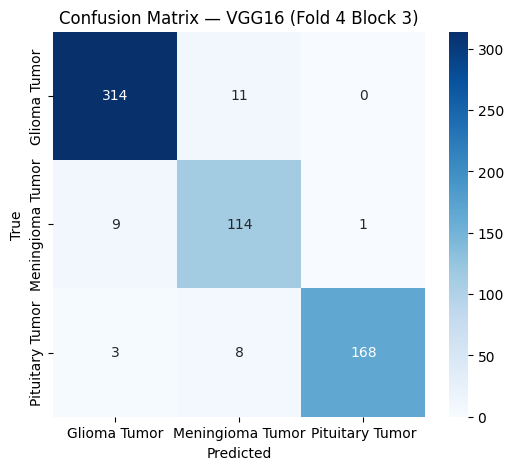

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0421 - accuracy: 0.9442 | val_loss: 0.0633 - val_accuracy: 0.9427
val_accuracy improved from 0.0000 to 0.9427, saving weights to /kaggle/working/VGG16_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0369 - accuracy: 0.9540 | val_loss: 0.0657 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9427


Epoch 3/50 | loss: 0.0407 - accuracy: 0.9479 | val_loss: 0.0616 - val_accuracy: 0.9443
val_accuracy improved from 0.9427 to 0.9443, saving weights to /kaggle/working/VGG16_block_2_fold_4.pth


Epoch 4/50 | loss: 0.0331 - accuracy: 0.9655 | val_loss: 0.0636 - val_accuracy: 0.9522
val_accuracy improved from 0.9443 to 0.9522, saving weights to /kaggle/working/VGG16_block_2_fold_4.pth


...

Epoch 6/50 | loss: 0.0293 - accuracy: 0.9635 | val_loss: 0.0633 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9522


Epoch 7/50 | loss: 0.0254 - accuracy: 0.9680 | val_loss: 0.0560 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9522


Epoch 8/50 | loss: 0.0253 - accuracy: 0.9700 | val_loss: 0.0606 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9522


Epoch 9/50 | loss: 0.0209 - accuracy: 0.9725 | val_loss: 0.0819 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9522


Epoch 10/50 | loss: 0.0270 - accuracy: 0.9709 | val_loss: 0.0571 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9522
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.063641  0.952229
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.96      0.97       325
Meningioma Tumor       0.86      0.93      0.89       124
 Pituitary Tumor       0.98      0.96      0.97       179

        accuracy                           0.95       628
       macro avg       0.94      0.95      0.94       628
    weighted avg       0.95      0.95      0.95       628



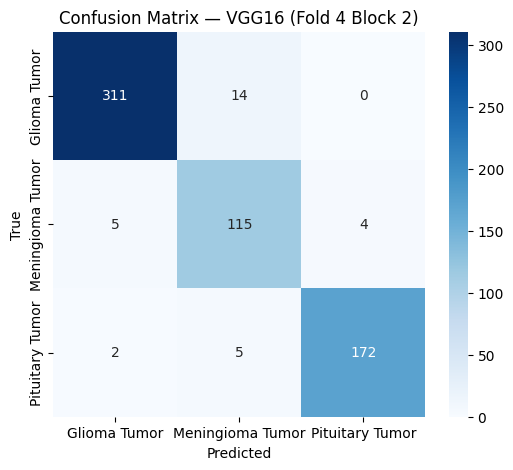

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0391 - accuracy: 0.9561 | val_loss: 0.0684 - val_accuracy: 0.9363
val_accuracy improved from 0.0000 to 0.9363, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0322 - accuracy: 0.9635 | val_loss: 0.0818 - val_accuracy: 0.9204
val_accuracy did not improve from 0.9363


Epoch 3/50 | loss: 0.0321 - accuracy: 0.9643 | val_loss: 0.0773 - val_accuracy: 0.9395
val_accuracy improved from 0.9363 to 0.9395, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


Epoch 4/50 | loss: 0.0208 - accuracy: 0.9741 | val_loss: 0.0690 - val_accuracy: 0.9522
val_accuracy improved from 0.9395 to 0.9522, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


...

Epoch 14/50 | loss: 0.0113 - accuracy: 0.9856 | val_loss: 0.0632 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9586


Epoch 15/50 | loss: 0.0151 - accuracy: 0.9811 | val_loss: 0.0610 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9586


Epoch 16/50 | loss: 0.0164 - accuracy: 0.9836 | val_loss: 0.0613 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9586


Epoch 17/50 | loss: 0.0097 - accuracy: 0.9881 | val_loss: 0.0621 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9586


Epoch 18/50 | loss: 0.0161 - accuracy: 0.9799 | val_loss: 0.0616 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9586
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.061258  0.958599
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.97      0.98       325
Meningioma Tumor       0.87      0.94      0.90       124
 Pituitary Tumor       0.98      0.95      0.97       179

        accuracy                           0.96       628
       macro avg       0.94      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



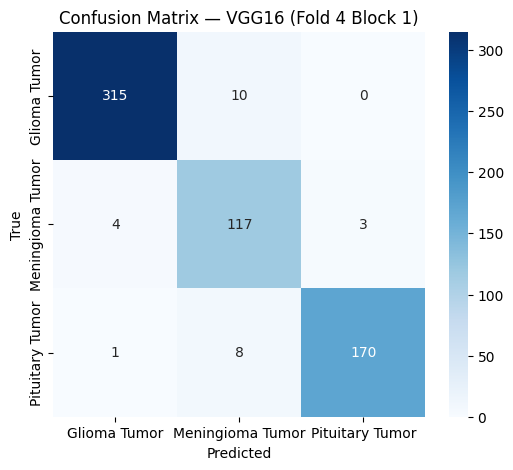

Fold: 5 block 6

Fold: 5 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 4.8925 - accuracy: 0.2871 | val_loss: 3.0387 - val_accuracy: 0.2784
val_accuracy improved from 0.0000 to 0.2784, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 2/50 | loss: 3.2543 - accuracy: 0.3606 | val_loss: 2.0197 - val_accuracy: 0.4230
val_accuracy improved from 0.2784 to 0.4230, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 3/50 | loss: 2.3931 - accuracy: 0.4548 | val_loss: 1.4223 - val_accuracy: 0.5117
val_accuracy improved from 0.4230 to 0.5117, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 4/50 | loss: 1.9472 - accuracy: 0.5262 | val_loss: 1.1267 - val_accuracy: 0.5941
val_accuracy improved from 0.5117 to 0.5941, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


...

Epoch 27/50 | loss: 0.2743 - accuracy: 0.7926 | val_loss: 0.3269 - val_accuracy: 0.7963
val_accuracy did not improve from 0.8009


Epoch 28/50 | loss: 0.3122 - accuracy: 0.7712 | val_loss: 0.3586 - val_accuracy: 0.7885
val_accuracy did not improve from 0.8009


Epoch 29/50 | loss: 0.2756 - accuracy: 0.7893 | val_loss: 0.3353 - val_accuracy: 0.7916
val_accuracy did not improve from 0.8009


Epoch 30/50 | loss: 0.2700 - accuracy: 0.7931 | val_loss: 0.3315 - val_accuracy: 0.7963
val_accuracy did not improve from 0.8009


Epoch 31/50 | loss: 0.2812 - accuracy: 0.7823 | val_loss: 0.3038 - val_accuracy: 0.7885
val_accuracy did not improve from 0.8009
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.354777  0.800933
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.84      0.85       287
Meningioma Tumor       0.66      0.55      0.60       166
 Pituitary Tumor       0.80      0.96      0.87       190

        accuracy                           0.80       643
       macro avg       0.78      0.78      0.78       643
    weighted avg       0.80      0.80      0.79       643



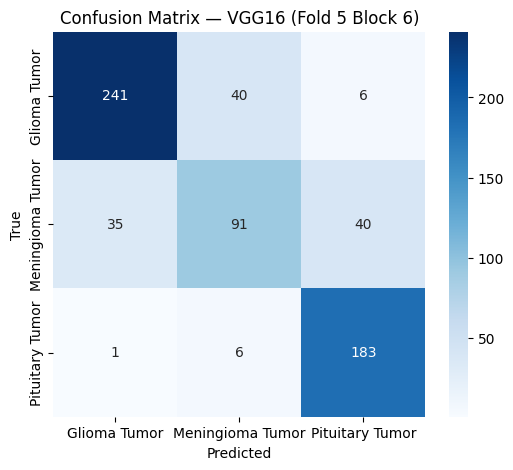

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.2740 - accuracy: 0.7621 | val_loss: 0.2541 - val_accuracy: 0.7932
val_accuracy improved from 0.0000 to 0.7932, saving weights to /kaggle/working/VGG16_block_5_fold_5.pth


Epoch 2/50 | loss: 0.1963 - accuracy: 0.7926 | val_loss: 0.2105 - val_accuracy: 0.8087
val_accuracy improved from 0.7932 to 0.8087, saving weights to /kaggle/working/VGG16_block_5_fold_5.pth


Epoch 3/50 | loss: 0.1694 - accuracy: 0.8174 | val_loss: 0.2352 - val_accuracy: 0.8040
val_accuracy did not improve from 0.8087


Epoch 4/50 | loss: 0.1438 - accuracy: 0.8422 | val_loss: 0.2546 - val_accuracy: 0.8040
val_accuracy did not improve from 0.8087


...

Epoch 9/50 | loss: 0.1190 - accuracy: 0.8633 | val_loss: 0.2291 - val_accuracy: 0.8134
val_accuracy did not improve from 0.8196


Epoch 10/50 | loss: 0.1136 - accuracy: 0.8686 | val_loss: 0.2134 - val_accuracy: 0.8180
val_accuracy did not improve from 0.8196


Epoch 11/50 | loss: 0.1058 - accuracy: 0.8802 | val_loss: 0.2151 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8196


Epoch 12/50 | loss: 0.1148 - accuracy: 0.8699 | val_loss: 0.2187 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8196


Epoch 13/50 | loss: 0.1081 - accuracy: 0.8798 | val_loss: 0.2148 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8196
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.211291  0.819596
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.87      0.88       287
Meningioma Tumor       0.69      0.57      0.62       166
 Pituitary Tumor       0.82      0.95      0.88       190

        accuracy                           0.82       643
       macro avg       0.80      0.80      0.79       643
    weighted avg       0.81      0.82      0.81       643



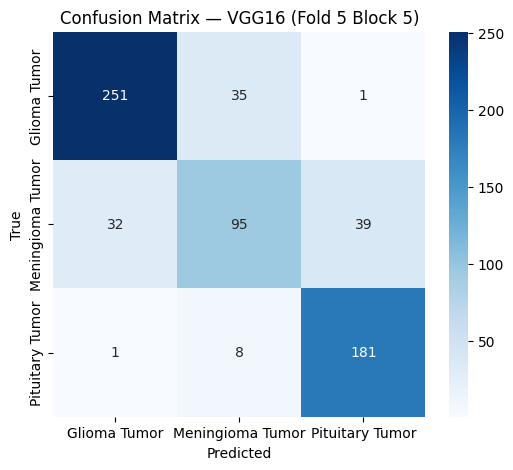

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1171 - accuracy: 0.8715 | val_loss: 0.2395 - val_accuracy: 0.8429
val_accuracy improved from 0.0000 to 0.8429, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0977 - accuracy: 0.8901 | val_loss: 0.2314 - val_accuracy: 0.8367
val_accuracy did not improve from 0.8429


Epoch 3/50 | loss: 0.0858 - accuracy: 0.9075 | val_loss: 0.2501 - val_accuracy: 0.8523
val_accuracy improved from 0.8429 to 0.8523, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


Epoch 4/50 | loss: 0.0787 - accuracy: 0.9091 | val_loss: 0.1900 - val_accuracy: 0.8585
val_accuracy improved from 0.8523 to 0.8585, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


...

Epoch 16/50 | loss: 0.0401 - accuracy: 0.9480 | val_loss: 0.2271 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8849


Epoch 17/50 | loss: 0.0422 - accuracy: 0.9471 | val_loss: 0.2279 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8849


Epoch 18/50 | loss: 0.0430 - accuracy: 0.9508 | val_loss: 0.2287 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8849


Epoch 19/50 | loss: 0.0342 - accuracy: 0.9575 | val_loss: 0.2274 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8849


Epoch 20/50 | loss: 0.0389 - accuracy: 0.9521 | val_loss: 0.2284 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8849
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.227191  0.884914
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.92      0.93       287
Meningioma Tumor       0.81      0.73      0.77       166
 Pituitary Tumor       0.86      0.97      0.91       190

        accuracy                           0.88       643
       macro avg       0.87      0.87      0.87       643
    weighted avg       0.88      0.88      0.88       643



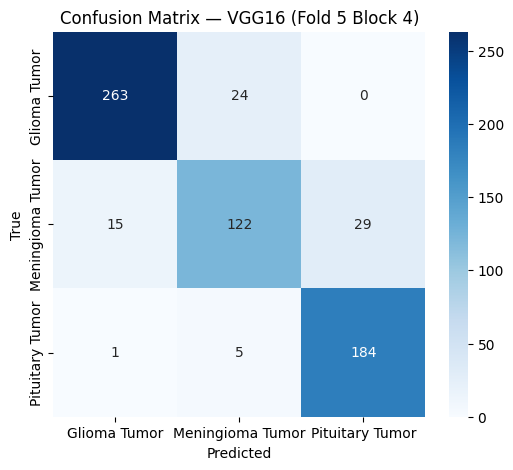

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0513 - accuracy: 0.9409 | val_loss: 0.2780 - val_accuracy: 0.8647
val_accuracy improved from 0.0000 to 0.8647, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0457 - accuracy: 0.9471 | val_loss: 0.1784 - val_accuracy: 0.8725
val_accuracy improved from 0.8647 to 0.8725, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


Epoch 3/50 | loss: 0.0348 - accuracy: 0.9591 | val_loss: 0.2397 - val_accuracy: 0.8849
val_accuracy improved from 0.8725 to 0.8849, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


Epoch 4/50 | loss: 0.0347 - accuracy: 0.9558 | val_loss: 0.2314 - val_accuracy: 0.8911
val_accuracy improved from 0.8849 to 0.8911, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


...

Epoch 14/50 | loss: 0.0200 - accuracy: 0.9752 | val_loss: 0.2600 - val_accuracy: 0.8974
val_accuracy did not improve from 0.8989


Epoch 15/50 | loss: 0.0213 - accuracy: 0.9715 | val_loss: 0.2636 - val_accuracy: 0.8958
val_accuracy did not improve from 0.8989


Epoch 16/50 | loss: 0.0201 - accuracy: 0.9769 | val_loss: 0.2666 - val_accuracy: 0.8942
val_accuracy did not improve from 0.8989


Epoch 17/50 | loss: 0.0204 - accuracy: 0.9740 | val_loss: 0.2687 - val_accuracy: 0.8958
val_accuracy did not improve from 0.8989


Epoch 18/50 | loss: 0.0256 - accuracy: 0.9703 | val_loss: 0.2669 - val_accuracy: 0.8958
val_accuracy did not improve from 0.8989
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.266005  0.898911
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.93      0.94       287
Meningioma Tumor       0.85      0.76      0.80       166
 Pituitary Tumor       0.87      0.97      0.92       190

        accuracy                           0.90       643
       macro avg       0.89      0.89      0.89       643
    weighted avg       0.90      0.90      0.90       643



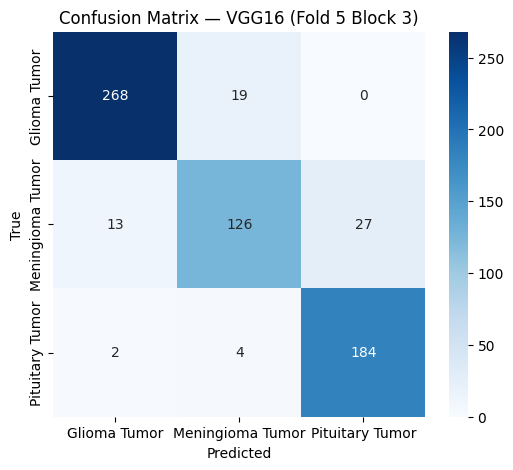

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0296 - accuracy: 0.9628 | val_loss: 0.3067 - val_accuracy: 0.8802
val_accuracy improved from 0.0000 to 0.8802, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0330 - accuracy: 0.9653 | val_loss: 0.2899 - val_accuracy: 0.8880
val_accuracy improved from 0.8802 to 0.8880, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


Epoch 3/50 | loss: 0.0187 - accuracy: 0.9752 | val_loss: 0.4419 - val_accuracy: 0.8694
val_accuracy did not improve from 0.8880


Epoch 4/50 | loss: 0.0245 - accuracy: 0.9711 | val_loss: 0.2754 - val_accuracy: 0.8942
val_accuracy improved from 0.8880 to 0.8942, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


...

Epoch 10/50 | loss: 0.0204 - accuracy: 0.9777 | val_loss: 0.3577 - val_accuracy: 0.8709
val_accuracy did not improve from 0.9020


Epoch 11/50 | loss: 0.0196 - accuracy: 0.9789 | val_loss: 0.3655 - val_accuracy: 0.8849
val_accuracy did not improve from 0.9020


Epoch 12/50 | loss: 0.0112 - accuracy: 0.9868 | val_loss: 0.4722 - val_accuracy: 0.8756
val_accuracy did not improve from 0.9020


Epoch 13/50 | loss: 0.0109 - accuracy: 0.9872 | val_loss: 0.3850 - val_accuracy: 0.8927
val_accuracy did not improve from 0.9020


Epoch 14/50 | loss: 0.0095 - accuracy: 0.9872 | val_loss: 0.3864 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9020
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.247129  0.902022
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.94      0.94       287
Meningioma Tumor       0.84      0.78      0.81       166
 Pituitary Tumor       0.90      0.94      0.92       190

        accuracy                           0.90       643
       macro avg       0.89      0.89      0.89       643
    weighted avg       0.90      0.90      0.90       643



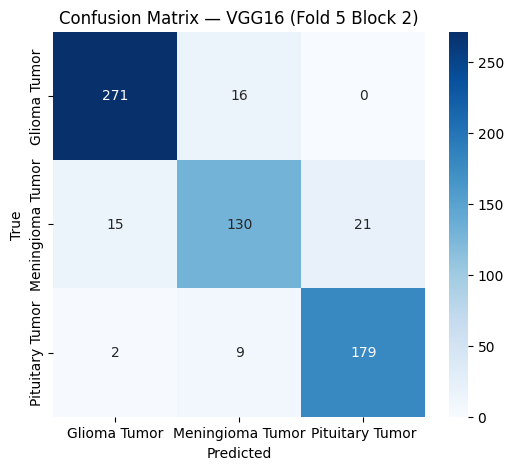

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0196 - accuracy: 0.9785 | val_loss: 0.2917 - val_accuracy: 0.8927
val_accuracy improved from 0.0000 to 0.8927, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0192 - accuracy: 0.9765 | val_loss: 0.2642 - val_accuracy: 0.8942
val_accuracy improved from 0.8927 to 0.8942, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


Epoch 3/50 | loss: 0.0133 - accuracy: 0.9810 | val_loss: 0.2839 - val_accuracy: 0.9005
val_accuracy improved from 0.8942 to 0.9005, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


Epoch 4/50 | loss: 0.0171 - accuracy: 0.9798 | val_loss: 0.2848 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9005


...

Epoch 11/50 | loss: 0.0066 - accuracy: 0.9913 | val_loss: 0.3834 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9082


Epoch 12/50 | loss: 0.0096 - accuracy: 0.9872 | val_loss: 0.3745 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9082


Epoch 13/50 | loss: 0.0067 - accuracy: 0.9893 | val_loss: 0.3688 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9082


Epoch 14/50 | loss: 0.0089 - accuracy: 0.9893 | val_loss: 0.3560 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9082


Epoch 15/50 | loss: 0.0083 - accuracy: 0.9917 | val_loss: 0.3600 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9082
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.342298  0.908243
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.95       287
Meningioma Tumor       0.88      0.75      0.81       166
 Pituitary Tumor       0.88      0.97      0.92       190

        accuracy                           0.91       643
       macro avg       0.90      0.89      0.89       643
    weighted avg       0.91      0.91      0.91       643



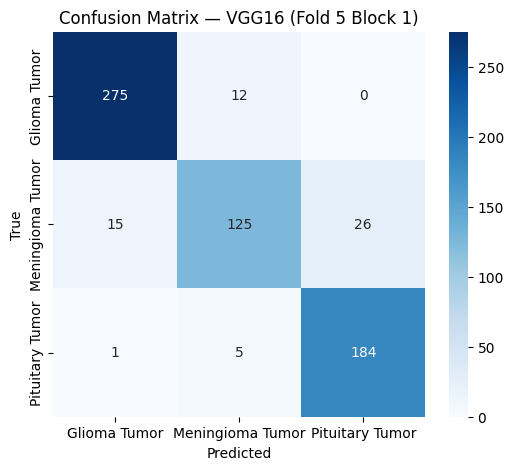

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 83.43%
Accuracy unfreeze block 5 - block 6: 88.42%
Accuracy unfreeze block 4 - block 6: 92.32%
Accuracy unfreeze block 3 - block 6: 92.99%
Accuracy unfreeze block 2 - block 6: 92.98%
Accuracy unfreeze block 1 - block 6: 93.82%
